# Задача регрессии

В случае задач машинного обучения с учителем существует какое-то количество размеченных данных, данных, для которых определен корректный ответ и корректное предсказание. Мы пытаемся обучить нашу модель на этих данных и потом сделать предсказание на новых данных, которых мы еще не видели. Далее когда поступают новые данные, не размеченные, наша обученная модель пытается предсказать для них ответ.

В этом разделе мы посмотрим на одну из задач машинного обучения с учителем - это задача регрессии.

**Задача регрессии** (прогнозирования) – построение модели, способной предсказывать численную величину на основе набора признаков объекта.

**Регрессия. Постановка задачи.**

Есть обучающая выборка, в которой представлены объекты в виде из признакового описания (вектор признаков) и значения целевой переменной (непрерывная переменная).

Алгоритм регрессии дл каждого нового объекта (его признакового описания) прогнозирует значение целевой переменной.

**Ответ в задачах регресии является числовым из непрерывного диапазона, в отличии от задач классификации, где ответ дискретный.**

# Линейная регрессия

Самый простой способ посчитать регрессиию, предположить, что есть некая линейная зависимость от признаков.

$$f_{w,b}(x) = wx + b$$

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score

!wget "https://raw.githubusercontent.com/ShadarRim/25AIMEPhI/refs/heads/main/a05_salary_data.csv"

Мы ещё отдельно разберём как считать ошибки, но, упрощённо говоря, достаточно считать квадрат разности между настоящими и посчитанными значениями.

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2$$

Подбирать параметры поможет градиентный спуск.

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}$$

$$b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Для него нужно посчитать производные ошибки по параметрам.

$$
\frac{\partial J(w,b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J(w,b)}{\partial w} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{w,b}(X^{(i)}) - y^{(i)})X^{(i)}
$$

In [ ]:
class CustomLinearRegression():

    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.w = None
        self.b = 0

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0

        for _ in range(self.iterations):
            self.update_weights(X, y, m)

    def update_weights(self, X, y, m):
        y_pred = np.dot(X, self.w) + self.b

        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b


In [ ]:
df = pd.read_csv( "a05_salary_data.csv" )

display(df.head(10))

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


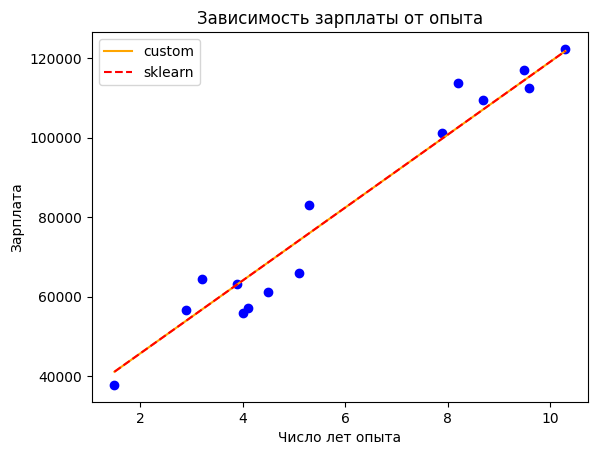

ПОДСЧЕТ ОШИБОК:

Кастомный LinReg
----------------
MSE: 35207447.00382104
R2 : 0.9528017130982512

Sklearn LinReg
--------------
MSE: 35207447.00483354
R2 : 0.952801713096894


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 1/2, random_state = 0)

model1 = CustomLinearRegression(iterations = 10000, learning_rate = 0.01)
model2 = LinearRegression()

model1.fit(X_train, Y_train)
model2.fit(X_train, Y_train)

Y_pred1 = model1.predict(X_test)
Y_pred2 = model2.predict(X_test)

indices = np.argsort(X_test[:, 0])

plt.scatter(X_test[indices], Y_test[indices], color = "blue")
plt.plot(X_test[indices], Y_pred1[indices], color = "orange", label="custom")
plt.plot(X_test[indices], Y_pred2[indices], "r--", label="sklearn")
plt.title("Зависимость зарплаты от опыта")
plt.xlabel("Число лет опыта")
plt.ylabel("Зарплата")
plt.legend()

plt.show()

print("ПОДСЧЕТ ОШИБОК:\n")
print("Кастомный LinReg\n----------------")
print("MSE:", mean_squared_error(Y_test, Y_pred1))
print("R2 :", r2_score(Y_test, Y_pred1))
print()
print("Sklearn LinReg\n--------------")
print("MSE:", mean_squared_error(Y_test, Y_pred2))
print("R2 :", r2_score(Y_test, Y_pred2))